# Project 02 (medium) — reference solution: rescuing a dirty data set

**Goal:** a realistically dirty order data set (500 orders of an online shop) is to
be made analysable: find the problems, treat them with justification, and prove with
an acceptance test that everything is clean.

**This is the fully worked solution.** All cells have been executed. The data come
from `generate_data.py` (fixed seed 42), which also documents the built-in problems.

**Reference to the script:** sections 2.1 (cleaning), 2.3 (groupby), 1.4 (box plot).

## 1. Inspect: what is wrong here?

**Task:** get an overview with `head()`, `info()`, `describe(include="all")` and some
samples, and note in the markdown cell below a list of all the problems you find.
(There are at least 6.)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH = "datasets/orders_raw.csv"
if not os.path.exists(PATH):
    PATH = "../" + PATH

raw = pd.read_csv(PATH)
print(raw.shape)
raw.head(8)

(515, 7)


,order_id,date,city,category,price,quantity,customer_age
0,10068,2024-01-13,Köln,Household,"50,13 EUR",4,61
1,10204,12.08.2024,cologne,Clothing,"117,11 EUR",3,51
2,10076,23.10.2024,Munich,Household,"188,76 EUR",1,33
3,10313,2024-05-10,Munich,Books,"42,69 EUR",1,27
4,10483,23.09.2024,Hamburg,Books,"58,78 EUR",4,24
5,10441,2024-04-02,Munich,Electronics,"86,02 EUR",3,76
6,10327,04.02.2024,hamburg,Electronics,"203,45 EUR",2,64
7,10159,25.06.2024,Hamburg,Clothing,"27,32 EUR",1,56


In [2]:
raw.info()
raw.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   order_id      515 non-null    int64 
 1   date          515 non-null    object
 2   city          515 non-null    object
 3   category      515 non-null    object
 4   price         502 non-null    object
 5   quantity      515 non-null    int64 
 6   customer_age  515 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 28.3+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,515.0,NaN,NaN,NaN,10247.013592,144.877279,10000.0,10121.5,10246.0,10372.5,10499.0
date,515,357,2024-02-13,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,515,15,Leipzig,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,515,4,Electronics,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,502,481,"104,74 EUR",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,515.0,NaN,NaN,NaN,3.017476,1.416168,1.0,2.0,3.0,4.0,5.0
customer_age,515.0,NaN,NaN,NaN,-3.574757,230.532609,-999.0,32.0,47.0,63.0,234.0


**Your list of problems** *(fill in here before reading on!)*:

1. ...
2. ...

<details><summary>For comparison: the complete list (unfold only after your own search)</summary>

1. `price` is text ("49,99 EUR") instead of a number — comma and unit
2. missing prices (empty fields → NaN)
3. extreme price outliers (four digits and more — looks like a decimal-point error)
4. `customer_age` contains the special code −999 (and at least one impossible value)
5. `city` inconsistent: capitalisation, spaces, spelling variants
6. `date` mixed in two formats (ISO and day-first)
7. duplicate rows (515 rows, but only 500 distinct `order_id`s?)
</details>

## 2. Duplicates

**Task:** how many exact duplicates are there? Remove them (result: `df`).
Then check whether `order_id` is unique too (otherwise there would be near-duplicates).

In [3]:
print("exact duplicates:", int(raw.duplicated().sum()))
df = raw.drop_duplicates().copy()
print("order_id unique:", df["order_id"].is_unique)
print("rows:", len(df))   # expected: 500

exact duplicates: 15
order_id unique: True
rows: 500


**Decision:** exact duplicates removed (15 of them) — identical rows including the
order id cannot be genuine repeat orders, they are an export error.

## 3. Price: text to number, missing values

**Task:** create a numeric column `price_eur` (remove the unit, comma to point,
`astype(float)` — empty fields should automatically become `NaN`).
How many prices are missing?

In [4]:
df["price_eur"] = (df["price"].str.replace(" EUR", "", regex=False)
                                .str.replace(",", ".", regex=False)
                                .astype(float))
print("missing prices:", df["price_eur"].isna().sum())   # expected: 12

missing prices: 12


**Decision:** the 12 missing prices stay `NaN` (no imputation): they are only 2.4 %
of the rows, pandas aggregations ignore NaN automatically, and filling an order price
with the median would feign a precision we do not have.

## 4. Outliers — the favourite trap

**Task (a):** apply the IQR rule (script 2.1) to `price_eur` **globally**.
How many rows are flagged? Look at the flagged prices — are they all errors?

In [5]:
q1, q3 = df["price_eur"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
mask_global = df["price_eur"] > upper
print(f"upper bound (global): {upper:.2f} EUR")
print("flagged rows:", int(mask_global.sum()))
print(sorted(df.loc[mask_global, "price_eur"].round(2), reverse=True)[:12])

upper bound (global): 288.21 EUR
flagged rows: 41
[19685.0, 18363.0, 1321.0, 392.75, 391.62, 389.8, 389.78, 387.99, 385.36, 382.14, 380.85, 380.62]


**41 flagged rows — but only 3 really look broken** (four digits and more).
The rest are expensive but plausible electronics prices. The global IQR rule compares
books with televisions — unfair. The box plot per category shows the problem:

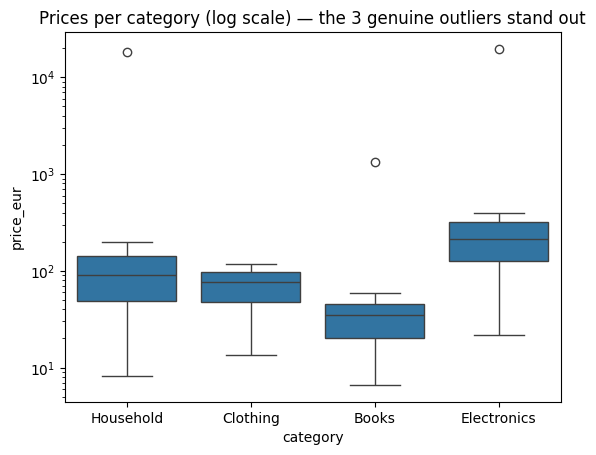

In [6]:
import seaborn as sns
sns.boxplot(data=df, x="category", y="price_eur")
plt.yscale("log")   # log scale, otherwise the outliers squash everything together
plt.title("Prices per category (log scale) — the 3 genuine outliers stand out")
plt.show()

**Task (b):** apply the IQR rule **per category**
(hint: `df.groupby("category")["price_eur"].transform(...)` with a function that
returns the upper bound per group). Now exactly **3** rows should be flagged.
Correct them: they are obviously decimal-point errors (factor 100) → divide by 100.

In [7]:
def upper_iqr_bound(g):
    q1, q3 = g.quantile([0.25, 0.75])
    return q3 + 1.5 * (q3 - q1)

bounds = df.groupby("category")["price_eur"].transform(upper_iqr_bound)
mask_group = df["price_eur"] > bounds
print("flagged rows (per category):", int(mask_group.sum()))
print(df.loc[mask_group, ["category", "price_eur"]].to_string(index=False))

df.loc[mask_group, "price_eur"] = df.loc[mask_group, "price_eur"] / 100
print("new maximum price:", df["price_eur"].max().round(2))

flagged rows (per category): 3
   category  price_eur
      Books     1321.0
Electronics    19685.0
  Household    18363.0
new maximum price: 392.75


**Decision:** 3 prices (1321 / 18363 / 19685 EUR) classified as decimal-point errors
and divided by 100 — the justification: they lie exactly two orders of magnitude above
what is usual for their category, and after the correction they fit inconspicuously
into the price band. *(In real life you would additionally check the source system.)*
Note the triad from script 2.1: error → correct; genuine extreme value → keep;
special code → NaN. Here we had errors — the expensive televisions above, by contrast,
were genuine extreme values and stay untouched!

## 5. Normalising the cities

**Task:** `df["city"].value_counts()` shows the chaos. Create `city_clean`:
strip spaces, lowercase, unify the spelling variants
(`münchen`→`munich`, `köln`→`cologne`), then `str.capitalize()`.
At the end: exactly **5** different cities.

In [8]:
print(df["city"].value_counts())

SPELLING = {"münchen": "munich", "köln": "cologne"}
df["city_clean"] = (df["city"].str.strip().str.lower()
                              .replace(SPELLING)
                              .str.capitalize())
print("\nafterwards:", sorted(df["city_clean"].unique()))
print("count:", df["city_clean"].nunique())   # expected: 5

city
Leipzig     54
leipzig     46
Köln        38
Hamburg     38
Munich      36
cologne     35
München     34
hamburg     32
Berlin      32
Hamburg     29
berlin      29
Cologne     29
 Berlin     26
munich      21
BERLIN      21
Name: count, dtype: int64

afterwards: ['Berlin', 'Cologne', 'Hamburg', 'Leipzig', 'Munich']
count: 5


## 6. Age: special code and plausibility

**Task:** `df["customer_age"].describe()` reveals two problems (look at min and max!).
Create `age`: replace the special code **−999** ("no answer") with `NaN` and also set
implausible ages (over 100) to `NaN`.

In [9]:
print(df["customer_age"].describe().round(1))

df["age"] = df["customer_age"].replace(-999, np.nan)
df.loc[df["age"] > 100, "age"] = np.nan
print("\nmissing:", df["age"].isna().sum(), "| range:", df["age"].min(), "-", df["age"].max())

count    500.0
mean      -3.3
std      229.4
min     -999.0
25%       32.0
50%       47.0
75%       62.0
max      234.0
Name: customer_age, dtype: float64

missing: 26 | range: 18.0 - 79.0


**Decision:** −999 is obviously a "no answer" code (25 times) → NaN.
The age 234 is physically impossible and the true value cannot be reconstructed → NaN
rather than guessing. In total 26 missing ages (5.2 %) — for analyses by age these rows
are left out automatically, the rest of the data set stays usable.

## 7. Date: two formats, one column

**Task:** `pd.to_datetime` with a fixed `format` and `errors="coerce"` parses only the
matching format (the rest becomes NaT). Parse both formats separately and combine them
with `fillna`. At the end: **0** NaT values.

In [10]:
iso = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="coerce")
day_first = pd.to_datetime(df["date"], format="%d.%m.%Y", errors="coerce")
df["date_clean"] = iso.fillna(day_first)

print("not parseable:", df["date_clean"].isna().sum())   # expected: 0
print(df["date_clean"].min(), "to", df["date_clean"].max())

not parseable: 0
2024-01-02 00:00:00 to 2024-12-28 00:00:00


## 8. Acceptance test

This cell is given as is. If it runs through without an error, your data set is
officially clean.

In [11]:
clean = df[["order_id", "date_clean", "city_clean", "category",
            "price_eur", "quantity", "age"]].rename(
                columns={"date_clean": "date", "city_clean": "city"})

assert len(clean) == 500, "duplicates not (properly) removed"
assert clean["order_id"].is_unique
assert clean["price_eur"].dtype == float and clean["price_eur"].isna().sum() == 12
assert clean["price_eur"].max() < 500, "price outliers not corrected"
assert clean["city"].nunique() == 5, "cities not fully normalised"
assert clean["age"].isna().sum() == 26 and clean["age"].max() <= 100
assert str(clean["date"].dtype).startswith("datetime64") and clean["date"].isna().sum() == 0
assert abs(clean["price_eur"].median() - 71.6) < 0.5, "prices are wrong (check the correction)"

print("ACCEPTANCE PASSED — the data set is clean.")
clean.head()

ACCEPTANCE PASSED — the data set is clean.


,order_id,date,city,category,price_eur,quantity,age
0,10068,2024-01-13,Cologne,Household,50.13,4,61.0
1,10204,2024-08-12,Cologne,Clothing,117.11,3,51.0
2,10076,2024-10-23,Munich,Household,188.76,1,33.0
3,10313,2024-05-10,Munich,Books,42.69,1,27.0
4,10483,2024-09-23,Hamburg,Books,58.78,4,24.0


## 9. The reward: the first real analysis

Now that the data are clean, the analysis is a three-liner — given as is.

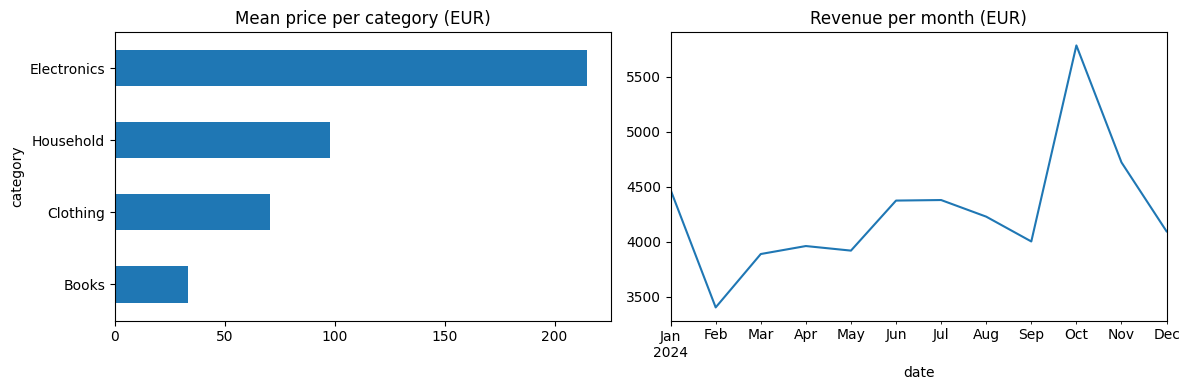

,orders,revenue,mean_age
city,,,
Berlin,108,9674.1,47.2
Cologne,102,10754.6,48.4
Hamburg,99,9819.9,48.9
Leipzig,100,11063.3,50.3
Munich,91,9924.0,49.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
clean.groupby("category")["price_eur"].mean().sort_values().plot.barh(ax=axes[0])
axes[0].set_title("Mean price per category (EUR)")
clean.set_index("date").resample("ME")["price_eur"].sum().plot(ax=axes[1])
axes[1].set_title("Revenue per month (EUR)")
plt.tight_layout(); plt.show()

clean.groupby("city").agg(orders=("order_id", "count"),
                          revenue=("price_eur", "sum"),
                          mean_age=("age", "mean")).round(1)

## Done — what you can do now

- *find* data problems systematically instead of only fixing them
- type conversion, duplicates, special codes, text normalisation, mixed date formats
- use the IQR rule correctly — including the lesson that it has to be applied
  **per group** when the groups live on different scales
- document cleaning decisions and secure them with an acceptance test

**Bonus tasks** (optional):
1. Open `generate_data.py` and compare: did you find all the built-in problems?
2. Change the seed in the generator — does your notebook still run through? (The
   acceptance numbers change; which checks can be formulated independently of the seed?)
3. Build a function `clean_data(df_raw)` that encapsulates all the steps — the first
   step from an analysis to a reusable pipeline.